# Segmentação de Imagens por Limiarização

Dataset: OralEpitheliumDB_Dataset (imagens saudáveis do conjunto de displasia — `Original ROI images`).

O objetivo desse notebook é compreender o conceito de Segmentação de Imagens e aplicar métodos clássicos de limiarização (thresholding) em imagens biomédicas (histológicas), comparando os resultados com máscaras de referência (Gold Standard) através da métrica DICE.

Serão implementadas três estratégias de limiarização:
1. Limiarização simples (manual)
2. Limiarização adaptativa
3. Limiarização com Otsu




## Configuração

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo dos gráficos
plt.rcParams['figure.figsize'] = (12, 5)


In [3]:
from pathlib import Path

HEALTHY_DIR = Path("/content/drive/MyDrive/Dados_Exploratorios/datasets/Original_ROI_images/healthy")

def list_images(folder: Path):
    # Retorna a lista de caminhos ordenados
    return sorted([str(p) for p in folder.glob("*.tif")])

healthy_paths = list_images(HEALTHY_DIR)
print(f"Imagens saudáveis encontradas: {len(healthy_paths)}")

Imagens saudáveis encontradas: 114


## Visualização


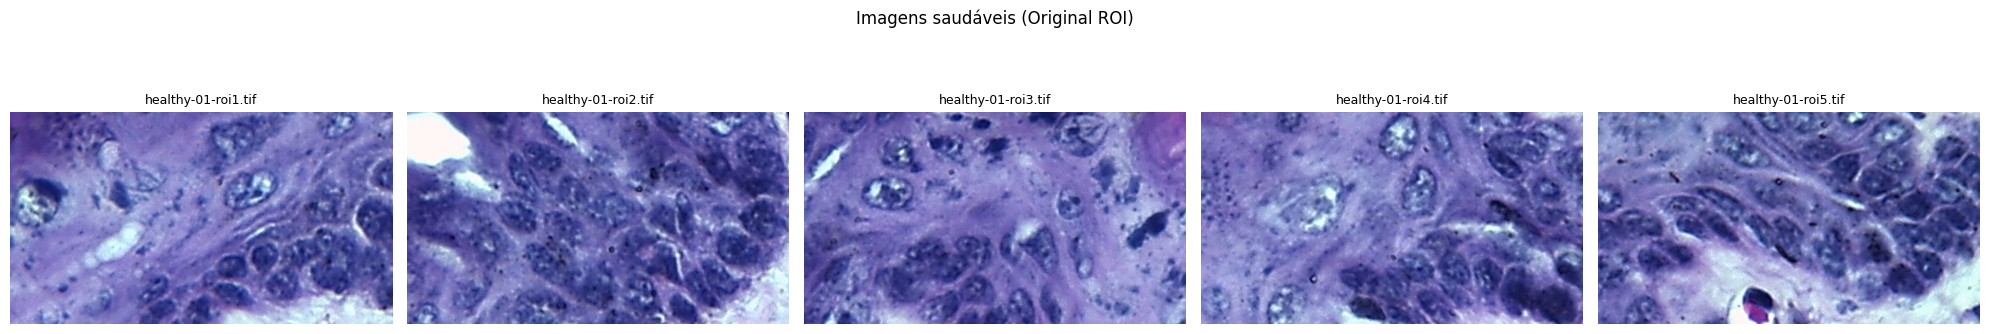

In [4]:
def show_images(paths, n=5, title="Exemplos"):
    n = min(n, len(paths))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, p in zip(axes, paths[:n]):
        img = cv2.imread(p)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(os.path.basename(p), fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_images(healthy_paths, n=5, title="Imagens saudáveis (Original ROI)")


## Pré-processamento

Segundo o capítulo Thresholding do livro Practical Python and OpenCV, o processo
padrão antes de aplicar qualquer técnica de limiarização é converter a imagem para escala de cinza (já que a limiarização trabalha sobre intensidade de um único canal) e aplicar um leve desfoque Gaussiano para remover ruídos e variações de alta frequência que atrapalham a definição de um limiar estável.

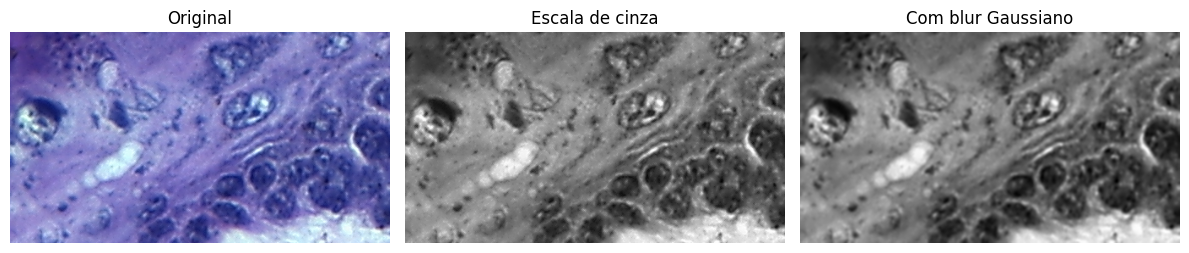

In [5]:
def preprocess(path, blur_ksize=(5, 5)):
    image = cv2.imread(path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, blur_ksize, 0)
    return image, gray, blurred

# Teste rápido
img_bgr, img_gray, img_blur = preprocess(healthy_paths[0])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(img_gray, cmap="gray"); axes[1].set_title("Escala de cinza"); axes[1].axis("off")
axes[2].imshow(img_blur, cmap="gray"); axes[2].set_title("Com blur Gaussiano"); axes[2].axis("off")
plt.tight_layout()
plt.show()


## 1 -Limiarização Simples

A limiarização simples exige um valor de limiar T definido manualmente. Todos os
pixels com intensidade abaixo de T viram 0 (preto) e os que estão acima viram 255
(branco), ou o inverso, dependendo do tipo escolhido.

No OpenCV isso é feito com `cv2.threshold(imagem, T, valor_max, tipo)`, onde o `tipo`
mais comum é `cv2.THRESH_BINARY` ou `cv2.THRESH_BINARY_INV` para inverter.

A principal limitação é que o valor de T precisa ser ajustado manualmente e pode não
funcionar bem se a imagem tiver grande variação de iluminação.


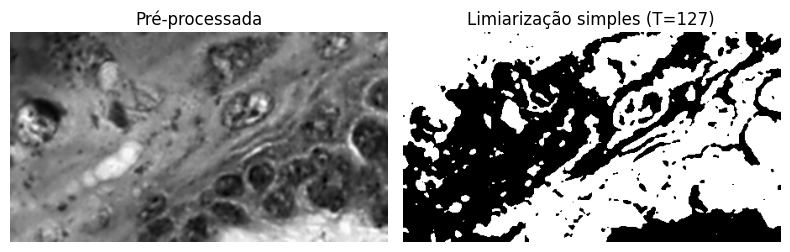

In [6]:
def simple_threshold(gray_blurred, T=127, invert=True):
    method = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, mask = cv2.threshold(gray_blurred, T, 255, method)
    return mask

# Teste rápido
mask_simple_demo = simple_threshold(img_blur, T=127, invert=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_blur, cmap="gray"); axes[0].set_title("Pré-processada"); axes[0].axis("off")
axes[1].imshow(mask_simple_demo, cmap="gray"); axes[1].set_title("Limiarização simples (T=127)"); axes[1].axis("off")
plt.tight_layout()
plt.show()


## 2 - Limiarização Adaptativa

A limiarização simples usa um único valor de T para toda a imagem, o que não
funciona bem quando há grande variação de iluminação entre regiões. A limiarização
adaptativa resolve isso calculando um T diferente para cada vizinhança de pixels. No OpenCV, `cv2.adaptiveThreshold` recebe o método de cálculo do limiar local, o tamanho da vizinhança e a constante C.


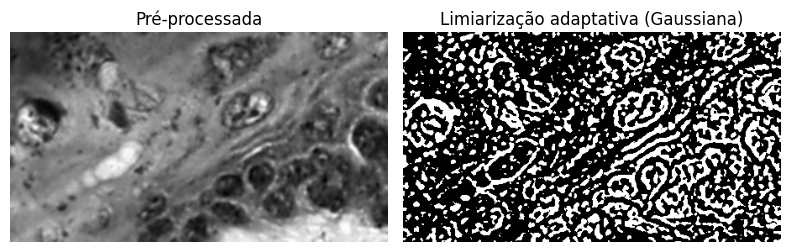

In [7]:
def adaptive_threshold(gray_blurred, method="gaussian", block_size=15, C=3, invert=True):
    adaptive_method = (cv2.ADAPTIVE_THRESH_GAUSSIAN_C if method == "gaussian"
                        else cv2.ADAPTIVE_THRESH_MEAN_C)
    thresh_type = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    mask = cv2.adaptiveThreshold(gray_blurred, 255, adaptive_method, thresh_type, block_size, C)
    return mask

# Teste rápido
mask_adapt_demo = adaptive_threshold(img_blur, method="gaussian", block_size=15, C=3)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_blur, cmap="gray"); axes[0].set_title("Pré-processada"); axes[0].axis("off")
axes[1].imshow(mask_adapt_demo, cmap="gray"); axes[1].set_title("Limiarização adaptativa (Gaussiana)"); axes[1].axis("off")
plt.tight_layout()
plt.show()


## 3 — Limiarização com Otsu

O método de Otsu resolve o problema de ter que escolher T manualmente: ele analisa o
histograma de intensidades da imagem e encontra automaticamente o valor de T que
melhor separa duas classes de pixels (fundo e objeto), minimizando a variância dentro
de cada classe.

O livro apresenta esse método usando a biblioteca `mahotas` (`mahotas.thresholding.otsu`), mas o próprio OpenCV já implementa Otsu nativamente, bastando somar a flag `cv2.THRESH_OTSU` ao `cv2.threshold`, nesse caso o valor de T informado é ignorado e calculado automaticamente. Usaremos a versão nativa do OpenCV para simplificar o pipeline.

Limiar encontrado pelo Otsu: 122.0


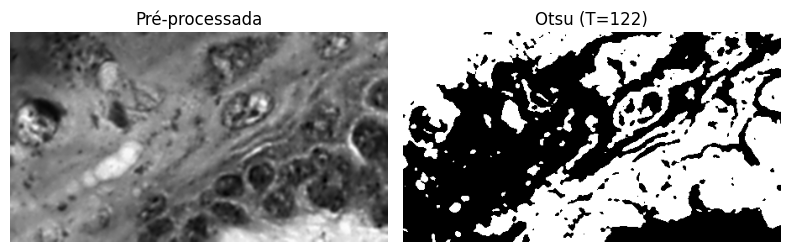

In [8]:
def otsu_threshold(gray_blurred, invert=True):
    method = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    T, mask = cv2.threshold(gray_blurred, 0, 255, method + cv2.THRESH_OTSU)
    return mask, T

# Teste rápido
mask_otsu_demo, T_otsu = otsu_threshold(img_blur)
print(f"Limiar encontrado pelo Otsu: {T_otsu}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_blur, cmap="gray"); axes[0].set_title("Pré-processada"); axes[0].axis("off")
axes[1].imshow(mask_otsu_demo, cmap="gray"); axes[1].set_title(f"Otsu (T={T_otsu:.0f})"); axes[1].axis("off")
plt.tight_layout()
plt.show()


## Comparação visual das três estratégias


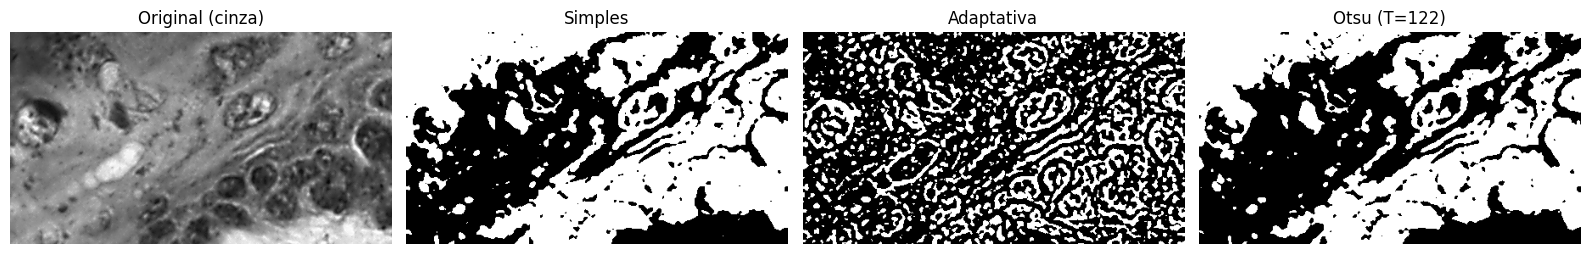

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_gray, cmap="gray"); axes[0].set_title("Original (cinza)"); axes[0].axis("off")
axes[1].imshow(mask_simple_demo, cmap="gray"); axes[1].set_title("Simples"); axes[1].axis("off")
axes[2].imshow(mask_adapt_demo, cmap="gray"); axes[2].set_title("Adaptativa"); axes[2].axis("off")
axes[3].imshow(mask_otsu_demo, cmap="gray"); axes[3].set_title(f"Otsu (T={T_otsu:.0f})"); axes[3].axis("off")
plt.tight_layout()
plt.show()


## Aplicação

Agora aplicamos as três estratégias de limiarização em todas as 114 imagens da pasta
`healthy`, gerando uma máscara segmentada por método para cada imagem.


In [10]:
results_masks = {}

for path in healthy_paths:
    filename = os.path.basename(path)
    _, gray, blurred = preprocess(path)

    mask_simple = simple_threshold(blurred, T=127, invert=True)
    mask_adaptive = adaptive_threshold(blurred, method="gaussian", block_size=15, C=3)
    mask_otsu, _ = otsu_threshold(blurred)

    results_masks[filename] = {
        "simple": mask_simple,
        "adaptive": mask_adaptive,
        "otsu": mask_otsu,
    }

print(f"Máscaras geradas para {len(results_masks)} imagens, 3 métodos cada.")


Máscaras geradas para 114 imagens, 3 métodos cada.


## Métrica DICE (Dice Similarity Coefficient)

A métrica DICE mede o grau de sobreposição entre duas máscaras binárias, no
nosso caso, a máscara gerada automaticamente por um método de limiarização e a máscara
de referência (Gold Standard, feita manualmente por especialistas). onde `A` é o conjunto de pixels da máscara predita e `B` o conjunto de pixels da máscara de referência.

- DICE próximo de 1 → forte sobreposição, a segmentação automática está muito
  parecida com a referência.
- DICE próximo de 0 → pouca ou nenhuma sobreposição, a segmentação está ruim.

A diferença entre "comparar pixels corretamente classificados" (acurácia pixel a
pixel) e "medir sobreposição entre máscaras" (DICE) é que a acurácia pode ser
enganosa em imagens onde o objeto de interesse ocupa uma pequena parte da imagem: uma máscara toda em preto pode ter alta acurácia (por acertar o fundo, que é a maioria dos pixels) mesmo sem detectar o objeto. O DICE, por focar na sobreposição das regiões de interesse, é mais sensível a esse tipo de erro e por isso é amplamente usado para avaliar segmentações,  especialmente em imagens médicas.


In [11]:
def dice_coefficient(mask_pred, mask_true):
    # Normaliza as máscaras para binário (0 ou 1)
    pred = (mask_pred > 0).astype(np.uint8)
    true = (mask_true > 0).astype(np.uint8)

    intersection = np.logical_and(pred, true).sum()
    total = pred.sum() + true.sum()

    if total == 0:
        return 1.0
    return (2.0 * intersection) / total


## Carregando as máscaras de referência (Gold Standard)

Precisamos carregar as máscaras correspondentes do conjunto
`Gold_Standard_Semantic_Segmentation` para comparar com nossas máscaras preditas.


In [12]:
GOLD_STANDARD_DIR = Path("/content/drive/MyDrive/Dados_Exploratorios/datasets/Gold_Standard_Semantic_Segmentation/healthy")

def get_mask_path(image_filename, gold_dir=GOLD_STANDARD_DIR):
    # As máscaras Gold Standard usam o mesmo nome da imagem original,
    # trocando a extensão de .tif (imagem) para .png (máscara).
    name_no_ext = os.path.splitext(image_filename)[0]
    return gold_dir / f"{name_no_ext}.png"

example_file = os.path.basename(healthy_paths[0])
example_mask_path = get_mask_path(example_file)
print(f"{example_file}  ->  {example_mask_path.name}")


healthy-01-roi1.tif  ->  healthy-01-roi1.png


## Calculando o DICE para cada imagem e cada método

Para cada imagem saudável, comparamos as três máscaras preditas (simples, adaptativa,
Otsu) com a respectiva máscara Gold Standard, calculando o DICE de cada uma. Os
resultados são organizados em uma tabela (`DataFrame`) com uma linha por imagem e uma
coluna por método.


In [13]:
rows = []

for filename, masks in results_masks.items():
    mask_path = get_mask_path(filename)
    gold_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    row = {"filename": filename}
    for method_name, pred_mask in masks.items():
        if pred_mask.shape != gold_mask.shape:
            gold_resized = cv2.resize(gold_mask, (pred_mask.shape[1], pred_mask.shape[0]),
                                       interpolation=cv2.INTER_NEAREST)
        else:
            gold_resized = gold_mask
        row[method_name] = dice_coefficient(pred_mask, gold_resized)
    rows.append(row)

df_dice = pd.DataFrame(rows)
df_dice.head()


,filename,simple,adaptive,otsu
0,healthy-01-roi1.tif,0.494685,0.408981,0.516153
1,healthy-01-roi2.tif,0.588036,0.472505,0.555983
2,healthy-01-roi3.tif,0.524430,0.451696,0.588814
3,healthy-01-roi4.tif,0.553389,0.463660,0.608272
4,healthy-01-roi5.tif,0.616692,0.470771,0.592597


## Tabela comparativa — média do DICE por método

Aqui calculamos a média e o desvio padrão do DICE de cada estratégia considerando todas as imagens avaliada.


In [14]:
summary = df_dice[["simple", "adaptive", "otsu"]].agg(["mean", "std"]).T
summary.columns = ["Média DICE", "Desvio Padrão"]
summary.index.name = "Método"
summary = summary.rename(index={"simple": "Limiarização simples",
                                 "adaptive": "Limiarização adaptativa",
                                 "otsu": "Otsu"})
summary


,Média DICE,Desvio Padrão
Método,,
Limiarização simples,0.537360,0.102104
Limiarização adaptativa,0.453585,0.055121
Otsu,0.559063,0.109458


Tabela final para o relatório:

| Método | Média DICE | Observações |
|---|---|---|
| Limiarização simples | 0.537360	 | 0.102104 |
| Limiarização adaptativa | 0.453585 | 0.055121 |
| Otsu | 0.559063 | 0.109458 |


## Exemplos visuais das segmentações

Visualização de exemplos onde cada
método teve o melhor e o pior desempenho (maior/menor DICE), comparando a
máscara predita com a máscara Gold Standard lado a lado.


--- Método: simple ---


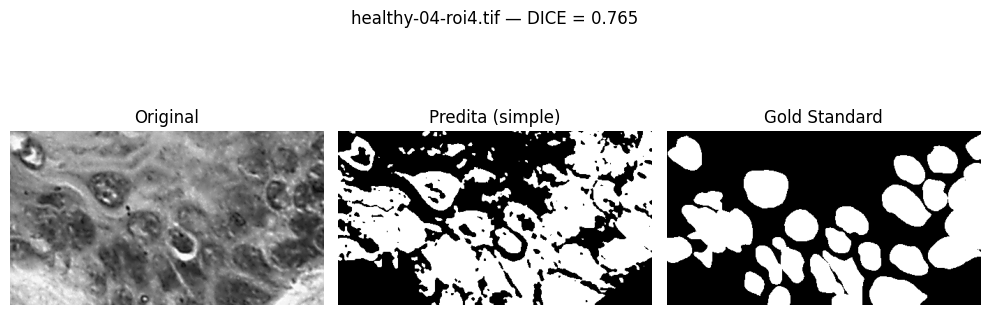

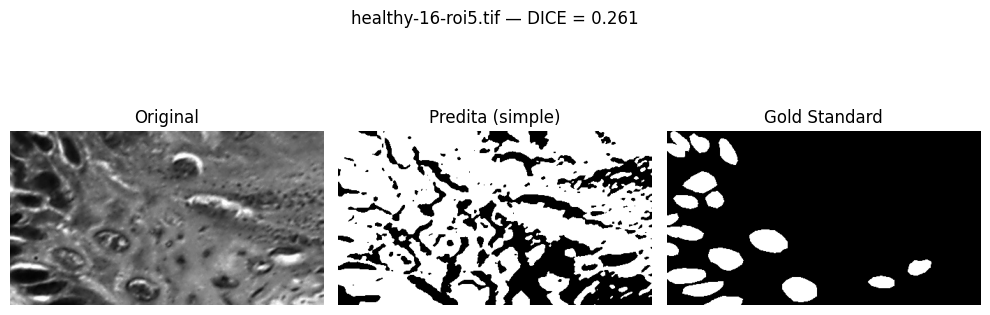

--- Método: adaptive ---


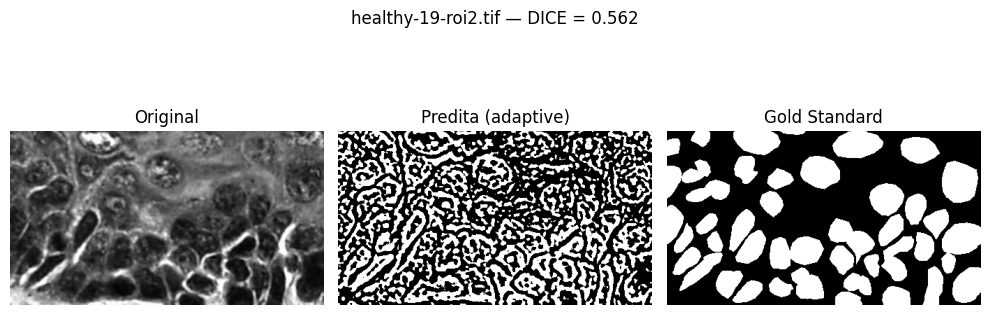

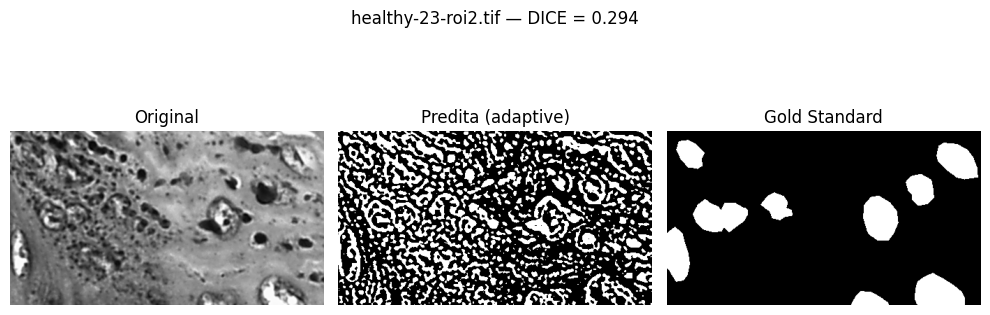

--- Método: otsu ---


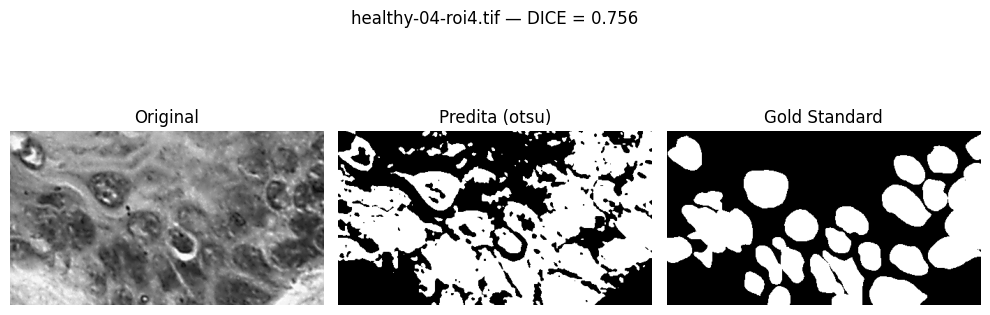

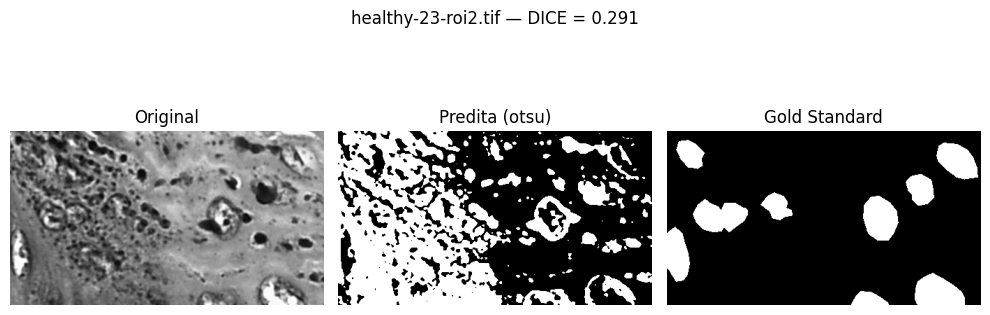

In [15]:
def show_case(filename, method):
    path = os.path.join(HEALTHY_DIR, filename)
    _, gray, _ = preprocess(path)
    pred_mask = results_masks[filename][method]
    gold_path = get_mask_path(filename)
    gold_mask = cv2.imread(str(gold_path), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    axes[0].imshow(gray, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(pred_mask, cmap="gray"); axes[1].set_title(f"Predita ({method})"); axes[1].axis("off")
    axes[2].imshow(gold_mask, cmap="gray"); axes[2].set_title("Gold Standard"); axes[2].axis("off")
    dice_val = df_dice.loc[df_dice["filename"] == filename, method].values[0]
    fig.suptitle(f"{filename} — DICE = {dice_val:.3f}")
    plt.tight_layout()
    plt.show()

for method in ["simple", "adaptive", "otsu"]:
    best_file = df_dice.loc[df_dice[method].idxmax(), "filename"]
    worst_file = df_dice.loc[df_dice[method].idxmin(), "filename"]
    print(f"--- Método: {method} ---")
    show_case(best_file, method)
    show_case(worst_file, method)


## Análise dos resultados


#### Qual método apresentou a melhor média DICE?

O Otsu teve a melhor média (0,559), levemente à frente da limiarização simples (0,537). A adaptativa ficou bem atrás (0,454). Ou seja, os dois métodos que usam um único limiar global para a imagem toda (simples e Otsu) funcionaram melhor que o método que analisa vizinhanças locais.

#### Algum método funcionou melhor em imagens com maior contraste?

Sim, nos casos de melhor DICE do Otsu e da simples, o epitélio aparece bem mais escuro (ou mais claro) que o fundo/estroma ao redor, uma diferença de intensidade clara e razoavelmente uniforme dentro de cada região. Quando essa diferença existe, um único limiar já separa bem as duas classes, é exatamente a situação em que a limiarização global (simples/Otsu) se sai melhor.

#### Algum método apresentou falhas em regiões com variação de iluminação?

A adaptativa foi a mais afetada. Nos piores casos dela, a máscara aparece bem mais "picotada" (ruidosa, tipo sal-e-pimenta) em vez de regiões contínuas, sintoma clássico de limiar local demais: como o tecido histológico tem textura interna (núcleos, citoplasma, variações de coloração), calcular um T diferente para cada janela de 15×15 pixels acaba criando muitos pequenos "furos" e ilhas que não existem na máscara Gold Standard, que é uma região contígua.

#### A limiarização simples foi suficiente para segmentar corretamente as imagens?

Parcialmente. Com DICE médio de 0,537 (desvio 0,10), ela captura razoavelmente a região do epitélio nas imagens onde o contraste ajuda, mas está longe de uma segmentação "correta" de forma consistente, um T fixo (127) não se adapta a imagens com iluminação de fundo variável, o que explica o desvio padrão relativamente alto.

#### O método de Otsu melhorou os resultados?

Sim, ainda que moderadamente. Otsu superou a simples em média (0,559 vs 0,537) porque calcula o limiar automaticamente a partir do histograma de cada imagem, logo se adapta a mudanças de brilho/contraste de imagem para imagem, em vez de usar sempre o mesmo T=127. Ainda assim o ganho é pequeno e o desvio padrão continua alto (0,109), sinal de que mesmo um T "ótimo" global não resolve quando há variação de iluminação dentro da própria imagem.

#### A limiarização adaptativa apresentou vantagens em relação às demais?

Na teoria, sim (é feita justamente para lidar com iluminação não uniforme), mas na prática, aqui, não trouxe vantagem: teve a pior média (0,454). O motivo mais provável é o tamanho da vizinhança (block_size=15) ser pequeno demais para a escala das estruturas do epitélio nessas imagens, o método acaba reagindo à textura interna do tecido (núcleos, citoplasma) em vez de à borda real entre epitélio e fundo, fragmentando a máscara. Ela tem, porém, o menor desvio padrão (0,055), é mais consistente, só que consistentemente pior.

#### Quais são as limitações dos métodos clássicos de segmentação nesse conjunto de imagens?

Nenhum dos três consegue diferenciar semanticamente "epitélio" de "outras estruturas escuras/claras", eles só separam por intensidade, então núcleos, vasos ou artefatos de coloração com intensidade parecida à do epitélio acabam entrando na máscara. Dependem de um único critério (intensidade de pixel), sem noção de forma, contexto ou continuidade da região. Precisam de ajuste manual de parâmetros (T, block_size, C) que funciona bem para umas imagens e mal para outras, não há um único conjunto de parâmetros ótimo para as 114 imagens ao mesmo tempo, o que se reflete nos desvios padrão do DICE.

#### Que dificuldades aparecem ao trabalhar com imagens histológicas?

Coloração (H&E ou similar) com variação de tom entre lâminas, textura interna densa do tecido (que "engana" métodos locais como o adaptativo), bordas difusas entre epitélio e estroma (ao contrário de um objeto bem definido, como as moedas do livro-base), e estruturas pequenas (núcleos) que têm intensidade parecida com a do fundo em algumas regiões, tudo isso reduz a eficácia de um critério baseado só em intensidade de pixel.